**Jakub Orchowski, s223281**

# CEL ĆWICZENIA
3D transformacje geometryczne i wypełnianie obszarów.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

# Zadania

## Zadanie 1.
Dla trójkąta o wierzchołkach $(0,0,0)$, $(1,0,0)$ i $(0,1,0)$ wyznaczam dwa rzuty po zadanych transformacjach 3D: rzut równoległy wzdłuż osi OZ oraz rzut perspektywiczny dla ogniskowej $f=1$.
W obu przypadkach wynik renderuję jako jasny kontur trójkąta na obrazie 400x400 pikseli, przy rozmiarze piksela $0.01 \times 0.01$.

In [2]:
IMAGE_SHAPE = (400, 400)
PIXEL_SIZE = (0.01, 0.01)
TRIANGLE_3D = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
])


def rpyt_matrix(roll, pitch, yaw, px, py, pz):
    """Buduje macierz jednorodną transformacji 3D zgodną z funkcją RPYT z materiałów."""
    r = np.deg2rad(roll)
    p = np.deg2rad(pitch)
    y = np.deg2rad(yaw)

    mr = np.array([
        [np.cos(r), -np.sin(r), 0.0],
        [np.sin(r), np.cos(r), 0.0],
        [0.0, 0.0, 1.0],
    ])
    mp = np.array([
        [np.cos(p), 0.0, np.sin(p)],
        [0.0, 1.0, 0.0],
        [-np.sin(p), 0.0, np.cos(p)],
    ])
    my = np.array([
        [1.0, 0.0, 0.0],
        [0.0, np.cos(y), -np.sin(y)],
        [0.0, np.sin(y), np.cos(y)],
    ])

    hmat = np.eye(4)
    hmat[:3, :3] = my @ mp @ mr
    hmat[:3, 3] = [px, py, pz]
    return hmat


def perspective_matrix(f):
    """Buduje macierz rzutu perspektywicznego zgodną z funkcją Persp z materiałów."""
    hmat = np.zeros((4, 4), dtype=float)
    hmat[0, 0] = 1.0
    hmat[1, 1] = 1.0
    hmat[3, 2] = -1.0 / f
    hmat[3, 3] = 1.0
    return hmat


def transform_points(points, hmat):
    """Przekształca zbiór punktów 3D macierzą jednorodną 4x4."""
    homogeneous = np.hstack([points, np.ones((points.shape[0], 1))])
    transformed = (hmat @ homogeneous.T).T
    return transformed[:, :3] / transformed[:, 3:4]


def project_parallel(points):
    """Realizuje rzut równoległy wzdłuż osi OZ."""
    return points[:, :2]


def project_perspective(points, f=1.0):
    """Realizuje rzut perspektywiczny i normalizację współrzędnych jednorodnych."""
    homogeneous = np.hstack([points, np.ones((points.shape[0], 1))])
    projected = (perspective_matrix(f) @ homogeneous.T).T
    if np.any(np.isclose(projected[:, 3], 0.0)):
        raise ValueError('Punkt leży na płaszczyźnie osobliwej rzutu perspektywicznego.')
    return projected[:, :2] / projected[:, 3:4]


def math_to_pixel(points, image_shape=IMAGE_SHAPE, pixel_size=PIXEL_SIZE):
    """Mapuje współrzędne matematyczne 2D na współrzędne pikselowe obrazu."""
    height, width = image_shape
    dx, dy = pixel_size
    x_pix = points[:, 0] / dx + width / 2.0
    y_pix = -points[:, 1] / dy + height / 2.0
    return np.column_stack([x_pix, y_pix])


def draw_line(image, y0, x0, y1, x1, value):
    """Rysuje odcinek algorytmem Bresenhama na obrazie monochromatycznym."""
    y0, x0, y1, x1 = [int(round(v)) for v in (y0, x0, y1, x1)]
    height, width = image.shape
    steep = abs(y1 - y0) > abs(x1 - x0)

    if steep:
        x0, y0 = y0, x0
        x1, y1 = y1, x1
        width, height = height, width

    if x0 > x1:
        x0, x1 = x1, x0
        y0, y1 = y1, y0

    dx = x1 - x0
    dy = abs(y1 - y0)
    sy = 1 if y1 >= y0 else -1
    error = 2 * dy - dx
    x, y = x0, y0

    for _ in range(dx + 1):
        if 0 <= x < width and 0 <= y < height:
            if steep:
                image[x, y] = value
            else:
                image[y, x] = value
        if error > 0:
            y += sy
            error -= 2 * dx
        error += 2 * dy
        x += 1

    return image


def render_triangle_outline(projected_points, image_shape=IMAGE_SHAPE, pixel_size=PIXEL_SIZE, line_value=200, background=0):
    """Renderuje kontur trójkąta po projekcji 2D."""
    canvas = np.full(image_shape, background, dtype=np.uint8)
    pixel_points = np.rint(math_to_pixel(projected_points, image_shape, pixel_size)).astype(int)
    edges = [(0, 1), (1, 2), (2, 0)]
    for start, end in edges:
        draw_line(
            canvas,
            pixel_points[start, 1],
            pixel_points[start, 0],
            pixel_points[end, 1],
            pixel_points[end, 0],
            line_value,
        )
    return canvas, pixel_points

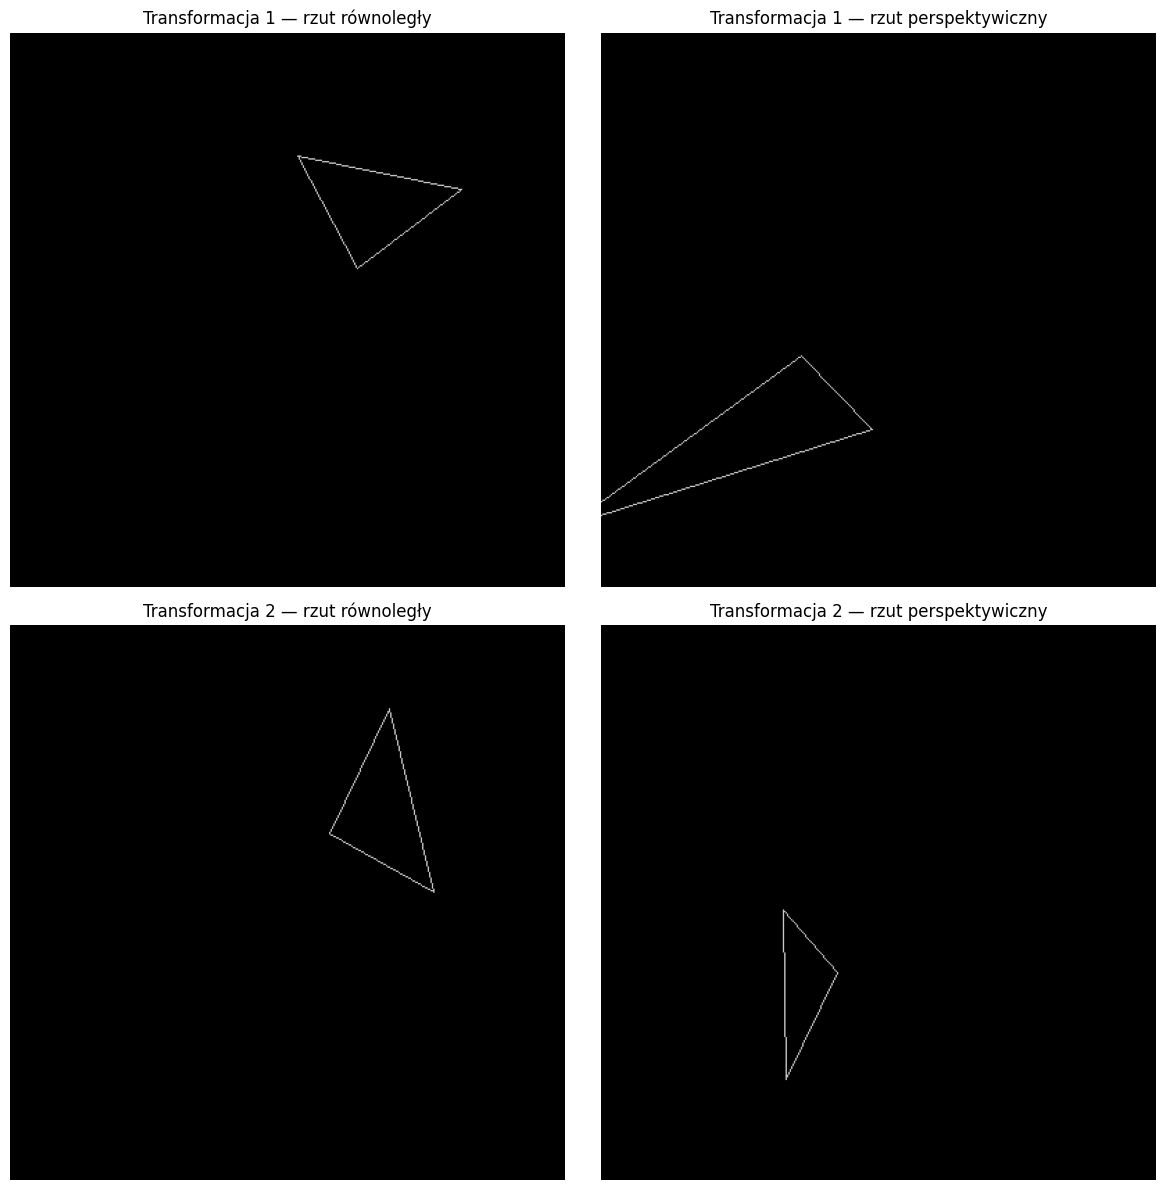

Transformacja 1
Współrzędne 3D po transformacji:
[[0.5   0.3   1.9  ]
 [1.25  0.868 1.56 ]
 [0.067 1.109 2.297]]
Rzut równoległy (w pikselach):
[[250 170]
 [325 113]
 [207  89]]
Rzut perspektywiczny (w pikselach):
[[144 233]
 [-23 355]
 [195 286]]

Transformacja 2
Współrzędne 3D po transformacji:
[[0.3   0.5   2.   ]
 [1.05  0.083 2.513]
 [0.733 1.396 2.096]]
Rzut równoległy (w pikselach):
[[230 150]
 [305 192]
 [273  60]]
Rzut perspektywiczny (w pikselach):
[[170 250]
 [131 205]
 [133 327]]



In [3]:
transform_specs = [
    {
        'name': 'Transformacja 1',
        'angles': (30.0, 30.0, 10.0),
        'translation': (0.5, 0.3, 1.9),
    },
    {
        'name': 'Transformacja 2',
        'angles': (-30.0, -30.0, -10.0),
        'translation': (0.3, 0.5, 2.0),
    },
]

results = []
for spec in transform_specs:
    hmat = rpyt_matrix(*spec['angles'], *spec['translation'])
    transformed = transform_points(TRIANGLE_3D, hmat)
    parallel_points = project_parallel(transformed)
    perspective_points = project_perspective(transformed, f=1.0)
    parallel_image, parallel_pixels = render_triangle_outline(parallel_points)
    perspective_image, perspective_pixels = render_triangle_outline(perspective_points)
    results.append({
        'name': spec['name'],
        'transformed': transformed,
        'parallel_points': parallel_points,
        'parallel_pixels': parallel_pixels,
        'parallel_image': parallel_image,
        'perspective_points': perspective_points,
        'perspective_pixels': perspective_pixels,
        'perspective_image': perspective_image,
    })

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for row, result in enumerate(results):
    axes[row, 0].imshow(result['parallel_image'], cmap='gray', vmin=0, vmax=255)
    axes[row, 0].set_title(f"{result['name']} — rzut równoległy")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(result['perspective_image'], cmap='gray', vmin=0, vmax=255)
    axes[row, 1].set_title(f"{result['name']} — rzut perspektywiczny")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

for result in results:
    print(result['name'])
    print('Współrzędne 3D po transformacji:')
    print(np.round(result['transformed'], 3))
    print('Rzut równoległy (w pikselach):')
    print(result['parallel_pixels'])
    print('Rzut perspektywiczny (w pikselach):')
    print(result['perspective_pixels'])
    print()

### Wnioski
Rzut równoległy zachowuje równoległość krawędzi i nie zależy od odległości obiektu od kamery, dlatego oba trójkąty mają bardziej zbliżone rozmiary na obrazie.
Rzut perspektywiczny zgodny z macierzą z materiałów wprowadza zmianę skali i odwrócenie zależne od położenia względem kamery, więc położenie w osi OZ mocniej wpływa na wynikowy obraz.

## Zadanie 2.
Implementuję funkcję `floodfill(Im, y, x, T, C)`, która wypełnia 4-spójny obszar o jasności `T`, rozpoczynając od piksela startowego `(y, x)`.
Działanie sprawdzam na kilku największych czarnych obszarach obrazu `BW.bmp`.

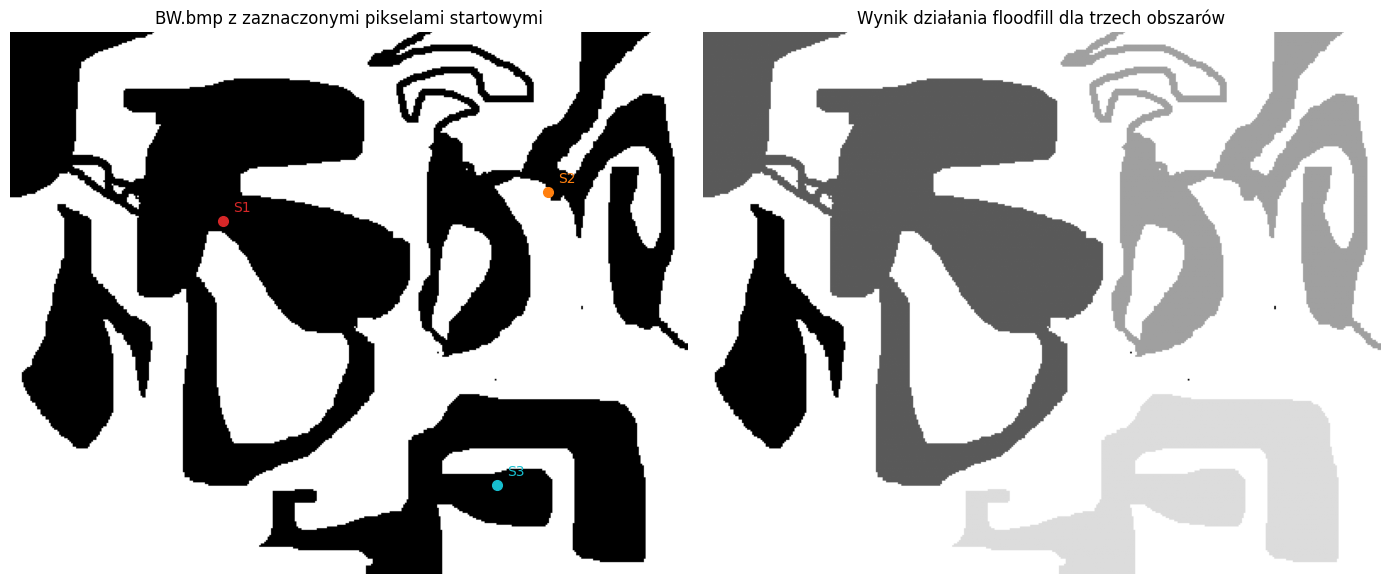

Obszar 1: seed=(np.int64(111), np.int64(125)), rozmiar=24814 px, bbox=(0, 0, 267, 235)
Obszar 2: seed=(np.int64(94), np.int64(317)), rozmiar=12733 px, bbox=(0, 211, 191, 399)
Obszar 3: seed=(np.int64(267), np.int64(287)), rozmiar=11674 px, bbox=(214, 147, 319, 374)


In [4]:
def floodfill(image, y, x, target_value, fill_value):
    """Wypełnia 4-spójny obszar o zadanej jasności metodą stosową."""
    output = image.copy()
    if output[y, x] != target_value:
        raise ValueError('Piksel startowy nie ma oczekiwanej jasności.')
    if target_value == fill_value:
        return output

    stack = [(y, x)]
    while stack:
        cy, cx = stack.pop()
        if cy < 0 or cy >= output.shape[0] or cx < 0 or cx >= output.shape[1]:
            continue
        if output[cy, cx] != target_value:
            continue
        output[cy, cx] = fill_value
        stack.append((cy - 1, cx))
        stack.append((cy + 1, cx))
        stack.append((cy, cx - 1))
        stack.append((cy, cx + 1))

    return output


def find_regions_by_value(image, target_value, min_size=1, count=None):
    """Znajduje największe 4-spójne obszary o wybranej jasności."""
    visited = np.zeros(image.shape, dtype=bool)
    regions = []

    for start_y in range(image.shape[0]):
        for start_x in range(image.shape[1]):
            if visited[start_y, start_x] or image[start_y, start_x] != target_value:
                continue

            stack = [(start_y, start_x)]
            visited[start_y, start_x] = True
            pixels = []

            while stack:
                cy, cx = stack.pop()
                pixels.append((cy, cx))
                for ny, nx in ((cy - 1, cx), (cy + 1, cx), (cy, cx - 1), (cy, cx + 1)):
                    if 0 <= ny < image.shape[0] and 0 <= nx < image.shape[1]:
                        if not visited[ny, nx] and image[ny, nx] == target_value:
                            visited[ny, nx] = True
                            stack.append((ny, nx))

            if len(pixels) < min_size:
                continue

            pixels_array = np.array(pixels)
            center = pixels_array.mean(axis=0)
            distances = np.sum((pixels_array - center) ** 2, axis=1)
            seed = tuple(pixels_array[np.argmin(distances)].astype(int))
            y_min, x_min = pixels_array.min(axis=0)
            y_max, x_max = pixels_array.max(axis=0)
            regions.append({
                'size': len(pixels),
                'seed': seed,
                'bbox': (int(y_min), int(x_min), int(y_max), int(x_max)),
            })

    regions.sort(key=lambda item: item['size'], reverse=True)
    if count is None:
        return regions
    return regions[:count]


bw_image = np.array(Image.open('BW.bmp').convert('L'), dtype=np.uint8)
selected_regions = find_regions_by_value(bw_image, target_value=0, min_size=4000, count=3)
fill_levels = [90, 160, 220]
filled_bw = bw_image.copy()
marker_colors = ['tab:red', 'tab:orange', 'tab:cyan']

for region, fill_level in zip(selected_regions, fill_levels):
    seed_y, seed_x = region['seed']
    filled_bw = floodfill(filled_bw, seed_y, seed_x, 0, fill_level)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(bw_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('BW.bmp z zaznaczonymi pikselami startowymi')
axes[0].axis('off')
for idx, region in enumerate(selected_regions, start=1):
    seed_y, seed_x = region['seed']
    axes[0].plot(seed_x, seed_y, 'o', color=marker_colors[idx - 1], markersize=7)
    axes[0].text(seed_x + 6, seed_y - 6, f'S{idx}', color=marker_colors[idx - 1], fontsize=10)

axes[1].imshow(filled_bw, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Wynik działania floodfill dla trzech obszarów')
axes[1].axis('off')

plt.tight_layout()
plt.show()

for idx, region in enumerate(selected_regions, start=1):
    print(
        f"Obszar {idx}: seed={region['seed']}, rozmiar={region['size']} px, bbox={region['bbox']}"
    )

### Wnioski
Implementacja stosowa poprawnie wypełnia rozłączne obszary bez używania rekurencji, więc nie grozi jej przepełnienie stosu Pythona.
Dla obrazu `BW.bmp` największe czarne regiony są dobrze rozdzielone, dzięki czemu łatwo wskazać piksele startowe i potwierdzić poprawność działania funkcji.

## Zadanie 3.
Powtarzam Zadanie 1, ale tym razem trójkąty są renderowane jako jasne, wypełnione obszary. Kontur tworzę algorytmem Bresenhama, a wnętrze domykam funkcją `floodfill`.

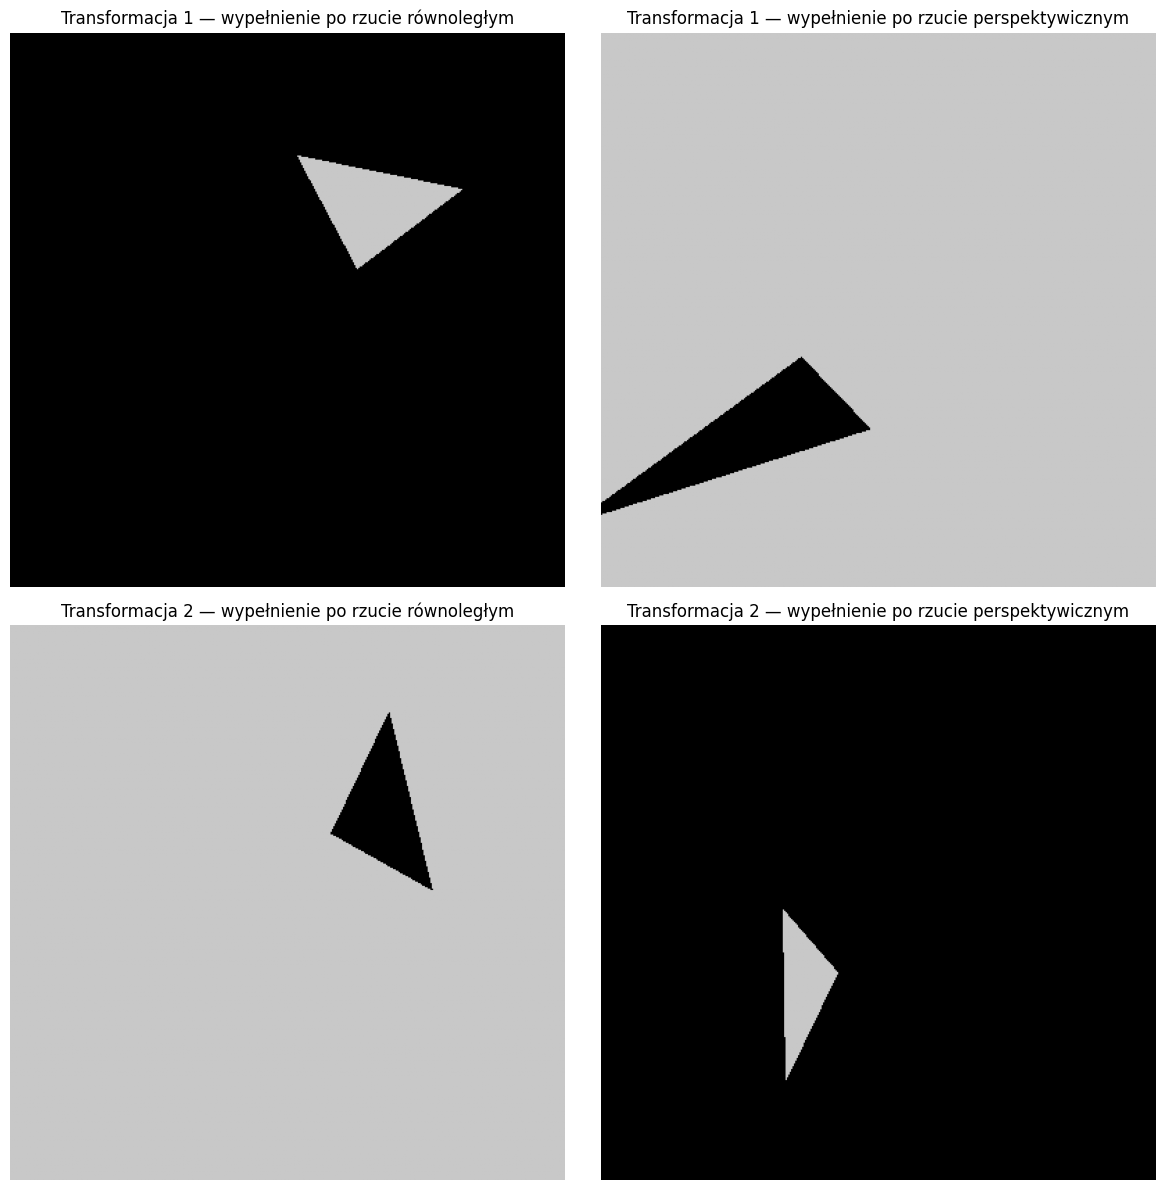

Transformacja 1: seed równoległy=(90, 209), seed perspektywiczny=(233, 143)
Transformacja 2: seed równoległy=(61, 272), seed perspektywiczny=(207, 132)


In [5]:
def point_in_triangle(point, triangle):
    """Sprawdza, czy punkt leży wewnątrz lub na brzegu trójkąta 2D."""
    point = np.asarray(point, dtype=float)
    triangle = np.asarray(triangle, dtype=float)
    a, b, c = triangle
    denominator = (b[1] - c[1]) * (a[0] - c[0]) + (c[0] - b[0]) * (a[1] - c[1])
    if np.isclose(denominator, 0.0):
        return False
    alpha = ((b[1] - c[1]) * (point[0] - c[0]) + (c[0] - b[0]) * (point[1] - c[1])) / denominator
    beta = ((c[1] - a[1]) * (point[0] - c[0]) + (a[0] - c[0]) * (point[1] - c[1])) / denominator
    gamma = 1.0 - alpha - beta
    return alpha >= 0.0 and beta >= 0.0 and gamma >= 0.0
def find_triangle_seed(pixel_points, canvas, background):
    """Szuka piksela wewnętrznego, od którego można uruchomić floodfill."""
    x_min = max(int(np.floor(pixel_points[:, 0].min())), 0)
    x_max = min(int(np.ceil(pixel_points[:, 0].max())), canvas.shape[1] - 1)
    y_min = max(int(np.floor(pixel_points[:, 1].min())), 0)
    y_max = min(int(np.ceil(pixel_points[:, 1].max())), canvas.shape[0] - 1)
    for y in range(y_min, y_max + 1):
        for x in range(x_min, x_max + 1):
            if point_in_triangle((x + 0.5, y + 0.5), pixel_points) and canvas[y, x] == background:
                return y, x
    raise ValueError('Nie udało się znaleźć piksela wewnętrznego trójkąta.')
def render_filled_triangle(projected_points, image_shape=IMAGE_SHAPE, pixel_size=PIXEL_SIZE, line_value=200, fill_value=200, background=0):
    """Renderuje wypełniony trójkąt z użyciem konturu i floodfill."""
    canvas, pixel_points = render_triangle_outline(
        projected_points,
        image_shape=image_shape,
        pixel_size=pixel_size,
        line_value=line_value,
        background=background,
    )
    seed_y, seed_x = find_triangle_seed(pixel_points, canvas, background)
    canvas = floodfill(canvas, seed_y, seed_x, background, fill_value)
    return canvas, pixel_points, (seed_y, seed_x)
filled_results = []
for spec in transform_specs:
    hmat = rpyt_matrix(*spec['angles'], *spec['translation'])
    transformed = transform_points(TRIANGLE_3D, hmat)
    parallel_points = project_parallel(transformed)
    perspective_points = project_perspective(transformed, f=1.0)
    parallel_image, parallel_pixels, parallel_seed = render_filled_triangle(parallel_points)
    perspective_image, perspective_pixels, perspective_seed = render_filled_triangle(perspective_points)
    filled_results.append({
        'name': spec['name'],
        'parallel_image': parallel_image,
        'parallel_pixels': parallel_pixels,
        'parallel_seed': parallel_seed,
        'perspective_image': perspective_image,
        'perspective_pixels': perspective_pixels,
        'perspective_seed': perspective_seed,
    })
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for row, result in enumerate(filled_results):
    axes[row, 0].imshow(result['parallel_image'], cmap='gray', vmin=0, vmax=255)
    axes[row, 0].set_title(f"{result['name']} — wypełnienie po rzucie równoległym")
    axes[row, 0].axis('off')
    axes[row, 1].imshow(result['perspective_image'], cmap='gray', vmin=0, vmax=255)
    axes[row, 1].set_title(f"{result['name']} — wypełnienie po rzucie perspektywicznym")
    axes[row, 1].axis('off')
plt.tight_layout()
plt.show()
for result in filled_results:
    print(
        f"{result['name']}: seed równoległy={result['parallel_seed']}, seed perspektywiczny={result['perspective_seed']}"
    )


### Wnioski
Po domknięciu konturu floodfill bez problemu znajduje całe wnętrze trójkąta, więc ta sama logika działa zarówno dla rzutu równoległego, jak i perspektywicznego.
W praktyce kluczowe jest znalezienie piksela rzeczywiście leżącego wewnątrz figury, dlatego przed wypełnieniem wyszukuję punkt należący do wnętrza trójkąta w układzie pikselowym.

## Zadanie 4.
Tworzę krótką animację, w której trójkąt obraca się od orientacji $[0^\circ, 0^\circ, 0^\circ]$ do $[30^\circ, 30^\circ, 10^\circ]$ i wraca do położenia początkowego.
Każda klatka powstaje po rzucie perspektywicznym, a obiekt jest wypełniony na ciemnoszarym tle o jasności 50.

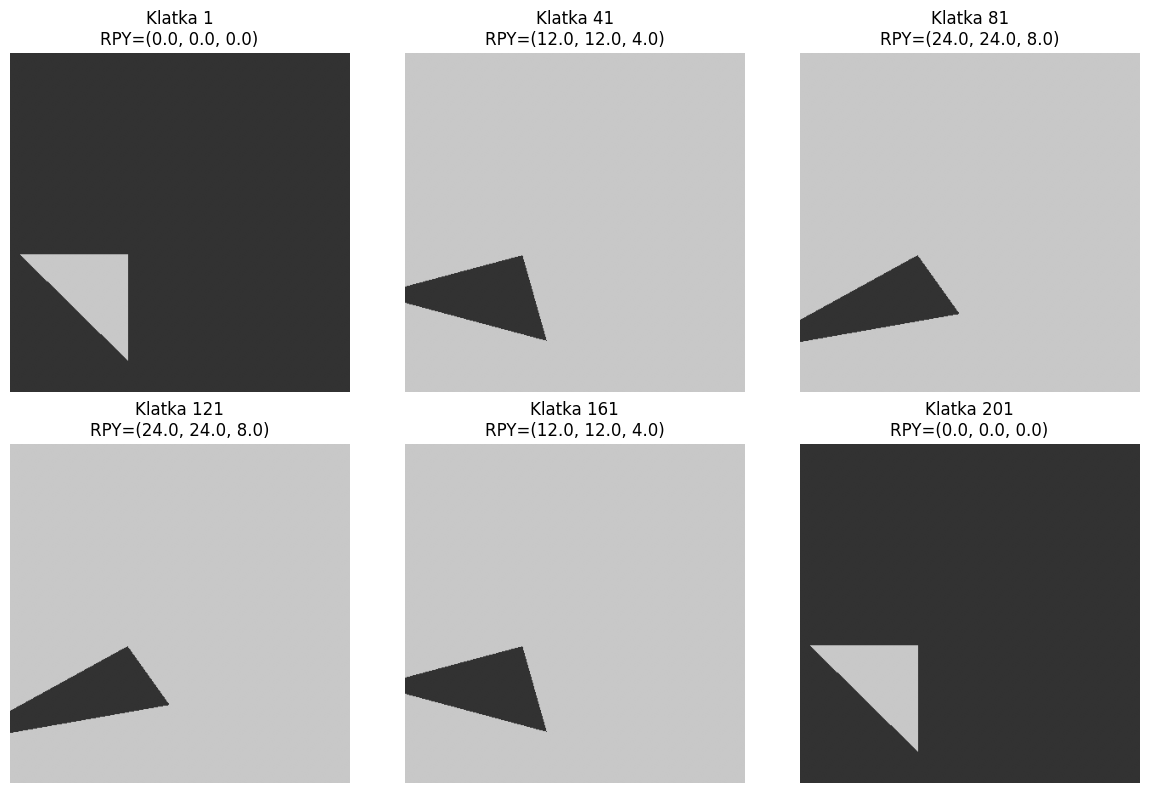

Zapisano animację do pliku zadanie4.gif. Liczba klatek: 201


In [6]:
import imageio.v2 as imageio

rotation_increment = np.array([0.3, 0.3, 0.1])
translation = (0.5, 0.3, 1.8)
forward_steps = np.arange(0, 101)
backward_steps = np.arange(99, -1, -1)
all_steps = np.concatenate([forward_steps, backward_steps])

frames = []
for step in all_steps:
    angles = step * rotation_increment
    hmat = rpyt_matrix(*angles, *translation)
    transformed = transform_points(TRIANGLE_3D, hmat)
    projected = project_perspective(transformed, f=1.0)
    frame, _, _ = render_filled_triangle(
        projected,
        line_value=200,
        fill_value=200,
        background=50,
    )
    frames.append(frame)

imageio.mimsave('zadanie4.gif', frames, duration=0.04)

sample_indices = np.linspace(0, len(frames) - 1, 6, dtype=int)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, frame_idx in zip(axes.ravel(), sample_indices):
    angles = all_steps[frame_idx] * rotation_increment
    ax.imshow(frames[frame_idx], cmap='gray', vmin=0, vmax=255)
    ax.set_title(
        f"Klatka {frame_idx + 1}\nRPY=({angles[0]:.1f}, {angles[1]:.1f}, {angles[2]:.1f})"
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Zapisano animację do pliku zadanie4.gif. Liczba klatek: {len(frames)}')

### Wnioski
Animacja pokazuje, że nawet przy stałym przesunięciu zmiana orientacji trójkąta istotnie wpływa na jego kształt po rzucie perspektywicznym.
Szare tło ułatwia ocenę granic figury i potwierdza, że floodfill poprawnie działa również wtedy, gdy jasność tła nie jest równa zero.